# Analista de Marketing i Estratégia Comercial: 06/07/2026
Quines característiques dels allotjaments
(equipaments, capacitat i ubicació) estan més relacionades amb els preus a cada ciutat?

## Análisis explicativo del precio — Fase 1 (Global) y Fase 2 (por ciudad)

Objetivo: cuantificar el peso de la capacidad, los equipamientos y la ciudad sobre
el precio de los alojamientos, mediante regresión lineal múltiple (MCO) sobre log(precio).

Enfoque explicativo, no predictivo. Punto de partida: dataset ya transformado
(flags de amenities por categoría, `logp` calculado). Los nulos de `price`/`accommodates`
y los duplicados de `apartment_id` se resuelven **dentro de este notebook** (decisión D6).

# Configuración del Entorno y Librerías
En este primer paso técnico, cargaremos las librerías necesarias para la manipulación de datos, la modelización econométrica mediante Mínimos Cuadrados Ordinarios (MCO) y la aplicación de los parches de robustez matemática para los contrastes.

* `pandas` y `numpy`: Para la carga de datos, limpieza de strings y transformaciones logarítmicas.
* `statsmodels`: Herramienta principal para ejecutar la regresión lineal múltiple y obtener los estadísticos de validación (R², p-valores y coeficientes).
* `scipy.stats`: Para las pruebas complementarias de distribución y diagnóstico de residuos.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 0. Carga del dataset transformado

Se importa **`Data/clean_dataset_06_07_2026.csv`**, que la fase de *Data Transformation* ha
enriquecido y sobrescrito: ya trae las 7 categorías de amenities como flags binarios `cat_*` y
`logp` calculado. Verificación rápida de dimensiones y de que las columnas esperadas
(`accommodates`, las 7 categorías, `city`, `logp`) están presentes antes de modelar.

In [2]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''Encuentra la carpeta raíz del proyecto subiendo desde el directorio actual.'''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}")

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_06_07_2026.csv'
print(f"Ruta resuelta: {ruta}")

df_original = pd.read_csv(ruta, parse_dates=['insert_date'])
df = df_original.copy()
print("Dimensiones:", df.shape)

Ruta resuelta: E:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Data\clean_dataset_06_07_2026.csv
Dimensiones: (7693, 54)


In [3]:
catcols = [c for c in df.columns if c.startswith('cat_')]
esperadas = ['accommodates', 'city', 'logp', 'price_€', 'apartment_id', 'insert_date'] + catcols
faltan = [c for c in esperadas if c not in df.columns]
print("Categorías de amenities (bloque de equipamientos):", catcols)
print("Columnas esperadas que faltan:", faltan if faltan else "ninguna ✓")
df[['apartment_id', 'city', 'accommodates', 'price_€', 'logp'] + catcols].head()

Categorías de amenities (bloque de equipamientos): ['cat_premium', 'cat_confort', 'cat_conectividad', 'cat_familia', 'cat_seguridad', 'cat_parking', 'cat_cocina']
Columnas esperadas que faltan: ninguna ✓


,apartment_id,city,accommodates,price_€,logp,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina
0,15695052,Barcelona,1,350.0,5.857933,1,1,1,0,0,0,1
1,14999488,Barcelona,2,250.0,5.521461,0,1,1,1,1,0,1
2,12265320,Barcelona,2,650.0,6.476972,0,1,1,0,0,0,1
3,16272738,Barcelona,2,760.0,6.633318,0,1,1,1,1,0,1
4,16262996,Barcelona,2,350.0,5.857933,0,0,1,0,1,0,1


## 1. Diagnóstico previo de los supuestos del modelo

Antes de ajustar cualquier regresión, se comprueba que los supuestos básicos de MCO
se sostienen sobre estos datos:
- Asimetría de `price` vs `logp` (para confirmar que el log corrige el sesgo).
- Multicolinealidad entre predictoras (VIF).
- Verificación de que no quedan duplicados de `apartment_id` que rompan la independencia de observaciones.

Como paso previo (secciones 1.1 y 1.2) se depuran nulos y duplicados **sólo sobre la copia de trabajo
de este análisis**; el diagnóstico numérico se realiza ya sobre datos depurados (sección 1.3).

## 1.1 Tratamiento de nulos en variables críticas

Se eliminan los registros con `price_€` o `accommodates` nulo (159 nulos de precio en el CSV limpio).
No se imputan, al ser las dos variables centrales del análisis explicativo — imputar aquí introduciría
sesgo directo en los coeficientes. Esta eliminación se hace una única vez, aquí, antes de la Fase 1 y la Fase 2.

In [4]:
n0 = len(df)
df = df.dropna(subset=['price_€', 'accommodates']).copy()
print(f"Filas: {n0} -> {len(df)}  (eliminados {n0 - len(df)} registros con price_€/accommodates nulo)")

Filas: 7693 -> 7534  (eliminados 159 registros con price_€/accommodates nulo)


## 1.2 Verificación y resolución de duplicados de `apartment_id`

Se confirma si existen duplicados de `apartment_id`. De existir, se conserva un único registro por
alojamiento (último snapshot según `insert_date`), para garantizar independencia de observaciones.

In [5]:
dups = int(df['apartment_id'].duplicated().sum())
print("Duplicados de apartment_id:", dups)
if dups > 0:
    df = (df.sort_values('insert_date')
            .drop_duplicates(subset='apartment_id', keep='last')
            .reset_index(drop=True))
    print("Resueltos ->", len(df), "filas.")
else:
    print("No hay duplicados (ya resueltos en Data Cleaning). apartment_id único:",
          df['apartment_id'].is_unique)

Duplicados de apartment_id: 0
No hay duplicados (ya resueltos en Data Cleaning). apartment_id único: True


### 1.3 Diagnóstico numérico: asimetría y multicolinealidad
Con los datos ya depurados, se verifica que el `log` corrige el sesgo del precio y que no hay
multicolinealidad relevante (VIF) entre las predictoras del modelo.

In [6]:
skew_price = stats.skew(df['price_€'])
skew_logp = stats.skew(df['logp'])
print(f"Asimetría price_€ -> logp:  {skew_price:.2f} -> {skew_logp:.2f}  (el log simetriza ✓)")

Xv = sm.add_constant(df[['accommodates'] + catcols])
vif = pd.DataFrame({'variable': Xv.columns,
                    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]})
print("\nVIF (excluida la constante):")
print(vif[vif['variable'] != 'const'].to_string(index=False))
print("\nVIF máximo:", round(vif.loc[vif['variable'] != 'const', 'VIF'].max(), 2),
      "-> sin multicolinealidad relevante ✓")

Asimetría price_€ -> logp:  2.08 -> 0.07  (el log simetriza ✓)

VIF (excluida la constante):
        variable      VIF
    accommodates 1.317681
     cat_premium 1.263413
     cat_confort 1.076321
cat_conectividad 1.097886
     cat_familia 1.221910
   cat_seguridad 1.083726
     cat_parking 1.214998
      cat_cocina 1.107803

VIF máximo: 1.32 -> sin multicolinealidad relevante ✓


## 2. Fase 1 — Modelo Global (ciudad como variable de control)

Se ajusta un único modelo de regresión múltiple sobre todo el dataset:
`log(precio) ~ capacidad + categorías de equipamientos + ciudad (dummies)`

Aquí la ciudad se incluye como variable de control, no como segmentación: el objetivo es aislar el
efecto neto de capacidad y equipamientos evitando que una ciudad cara infle artificialmente esos
coeficientes. Se usan errores estándar robustos (**HC3**) para corregir la heterocedasticidad.

In [7]:
formula1 = "logp ~ accommodates + " + " + ".join(catcols) + " + C(city)"
m1 = smf.ols(formula1, data=df).fit(cov_type="HC3")
print(f"Fase 1 · R² = {m1.rsquared:.3f}   ·   n = {int(m1.nobs)}")
print(formula1)

Fase 1 · R² = 0.495   ·   n = 7534
logp ~ accommodates + cat_premium + cat_confort + cat_conectividad + cat_familia + cat_seguridad + cat_parking + cat_cocina + C(city)


## 3. Fase 1 — Lectura de resultados del modelo global

Interpretación de los coeficientes:
- **β estandarizados** (comparables entre sí) de `accommodates` y de cada categoría de equipamientos.
- **Significatividad** estadística de cada término (p-valor con HC3).
- Efecto de la **ciudad** respecto a la de referencia (dummy base).

Responde a "en promedio, en toda España, qué pesa más" — todavía no a "en cada ciudad" (Fase 2).

In [8]:
# β estandarizados: se estandariza logp y las predictoras para que los coeficientes sean comparables
z = df.copy()
for c in ['logp', 'accommodates'] + catcols:
    sd = z[c].std()
    z[c] = (z[c] - z[c].mean()) / sd if sd > 0 else 0.0
mz = smf.ols(formula1, data=z).fit()

tabla = pd.DataFrame({
    "beta_std": mz.params[['accommodates'] + catcols].round(3),
    "p_value": m1.pvalues[['accommodates'] + catcols]
})
tabla["signif (p<0.05)"] = np.where(tabla["p_value"] < 0.05, "sí", "no")
print("Coeficientes estandarizados — Fase 1 (ordenados por peso):")
tabla.sort_values("beta_std", ascending=False)

Coeficientes estandarizados — Fase 1 (ordenados por peso):


,beta_std,p_value,signif (p<0.05)
accommodates,0.559,0.000000e+00,sí
cat_familia,0.094,7.725570e-23,sí
cat_premium,0.067,2.007529e-11,sí
cat_confort,0.064,4.204916e-13,sí
cat_cocina,0.028,3.468397e-03,sí
cat_parking,-0.018,4.911992e-02,sí
cat_conectividad,-0.025,9.884364e-03,sí
cat_seguridad,-0.029,1.115670e-03,sí


In [9]:
# Efecto de la ciudad (respecto a la ciudad base de la dummy), en % sobre el precio
city_terms = [p for p in m1.params.index if p.startswith("C(city)")]
efecto_city = pd.DataFrame({
    "coef_log": m1.params[city_terms].round(3),
    "efecto_%": ((np.exp(m1.params[city_terms]) - 1) * 100).round(1),
    "p_value": m1.pvalues[city_terms].round(4)
}).sort_values("efecto_%", ascending=False)
print("Efecto de cada ciudad respecto a la base (dummy de referencia):")
efecto_city

Efecto de cada ciudad respecto a la base (dummy de referencia):


,coef_log,efecto_%,p_value
C(city)[T.Mallorca],0.241,27.2,0.0000
C(city)[T.Menorca],0.186,20.5,0.0000
C(city)[T.Sevilla],0.015,1.5,0.6584
C(city)[T.Girona],-0.029,-2.8,0.1839
C(city)[T.Madrid],-0.081,-7.8,0.0000
C(city)[T.Málaga],-0.188,-17.2,0.0000
C(city)[T.Valencia],-0.277,-24.2,0.0000


## 4. Fase 1 — Reparto de varianza por bloque (Eta cuadrado)

Cálculo del **η² agrupado** por bloque (capacidad / bloque de amenities / ciudad) mediante ANOVA
tipo II. Cuantifica qué % de la variabilidad total del precio explica cada bloque en conjunto,
complementando la lectura de coeficientes con una visión de "peso relativo" fácil de comunicar.

In [10]:
an = sm.stats.anova_lm(smf.ols(formula1, data=df).fit(), typ=2)
tot = an["sum_sq"].sum()
bloques = {"capacidad": ["accommodates"], "amenities (bloque)": catcols, "ciudad": ["C(city)"]}
eta = {b: round(100 * an.loc[terms, "sum_sq"].sum() / tot, 1) for b, terms in bloques.items()}
eta["residual (no explicado)"] = round(100 - sum(eta.values()), 1)
print("η²  (% de la varianza TOTAL del precio explicada por cada bloque):")
for b, v in eta.items():
    print(f"   {b:28s}: {v:5.1f} %")

η²  (% de la varianza TOTAL del precio explicada por cada bloque):
   capacidad                   :  28.2 %
   amenities (bloque)          :   2.1 %
   ciudad                      :   3.5 %
   residual (no explicado)     :  66.2 %


## 5. Fase 2 — Modelos locales (uno por ciudad)

Se ajusta un modelo independiente por ciudad: `log(precio) ~ capacidad + categorías de equipamientos`.
Aquí la ciudad ya no es control sino **segmentación**: cada modelo responde directamente a la pregunta
de negocio ("¿qué características pesan más en CADA ciudad?"). Se registra, por ciudad: n, R², η² de
capacidad y de amenities, la categoría de equipamiento con mayor peso, y la matriz de β estandarizados
(para el heatmap de la sección 7).

In [11]:
formula2 = "logp ~ accommodates + " + " + ".join(catcols)
predictors = ['accommodates'] + catcols

def zscore(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0.0

rows = []
beta_matrix = {}   # ciudad -> {predictor: beta_std}
for city, sub in df.groupby('city'):
    sub = sub.copy()
    m2 = smf.ols(formula2, data=sub).fit(cov_type="HC3")
    an2 = sm.stats.anova_lm(smf.ols(formula2, data=sub).fit(), typ=2)
    tot2 = an2["sum_sq"].sum()
    e_cap = 100 * an2.loc["accommodates", "sum_sq"] / tot2
    e_am = 100 * an2.loc[catcols, "sum_sq"].sum() / tot2

    z2 = sub.copy()
    z2['logp'] = zscore(z2['logp'])
    for c in predictors:
        z2[c] = zscore(z2[c])
    mz2 = smf.ols(formula2, data=z2).fit()
    betas = {p: mz2.params.get(p, np.nan) for p in predictors}
    beta_matrix[city] = betas

    top_cat = max(catcols, key=lambda c: abs(betas[c]))
    rows.append(dict(ciudad=city, n=len(sub), R2=round(m2.rsquared, 2),
                     eta2_capac=round(e_cap, 1), eta2_amen=round(e_am, 1),
                     top_amenity=top_cat.replace('cat_', ''), beta_top=round(betas[top_cat], 2)))

fase2 = pd.DataFrame(rows).sort_values("eta2_amen", ascending=False).reset_index(drop=True)
fase2

,ciudad,n,R2,eta2_capac,eta2_amen,top_amenity,beta_top
0,Menorca,161,0.50,36.7,8.0,confort,0.21
1,Sevilla,400,0.29,21.1,5.0,familia,0.12
2,Málaga,393,0.30,19.4,4.8,familia,0.19
3,Madrid,1623,0.41,28.3,3.6,familia,0.12
4,Barcelona,2227,0.45,29.9,2.8,familia,0.14
5,Mallorca,1192,0.40,29.7,2.6,premium,0.15
6,Valencia,357,0.41,31.6,2.6,confort,0.10
7,Girona,1181,0.36,30.3,1.9,premium,0.10


## 6. Fase 2 — Comparación entre ciudades

Peso relativo de **capacidad** frente al **bloque de equipamientos** en cada mercado local
(normalizado a 100 % sobre la suma de ambos η²). Se presta atención a los casos con n bajo
(Menorca, Valencia, Málaga, Sevilla), donde R² y coeficientes son menos fiables.

In [12]:
d = fase2.copy()
d["cap_%"] = (100 * d["eta2_capac"] / (d["eta2_capac"] + d["eta2_amen"])).round(0)
d["amen_%"] = (100 - d["cap_%"]).round(0)
print("Peso relativo capacidad vs. equipamientos por ciudad (normalizado a 100%):")
d[["ciudad", "n", "R2", "eta2_capac", "eta2_amen", "cap_%", "amen_%", "top_amenity"]]

Peso relativo capacidad vs. equipamientos por ciudad (normalizado a 100%):


,ciudad,n,R2,eta2_capac,eta2_amen,cap_%,amen_%,top_amenity
0,Menorca,161,0.50,36.7,8.0,82.0,18.0,confort
1,Sevilla,400,0.29,21.1,5.0,81.0,19.0,familia
2,Málaga,393,0.30,19.4,4.8,80.0,20.0,familia
3,Madrid,1623,0.41,28.3,3.6,89.0,11.0,familia
4,Barcelona,2227,0.45,29.9,2.8,91.0,9.0,familia
5,Mallorca,1192,0.40,29.7,2.6,92.0,8.0,premium
6,Valencia,357,0.41,31.6,2.6,92.0,8.0,confort
7,Girona,1181,0.36,30.3,1.9,94.0,6.0,premium


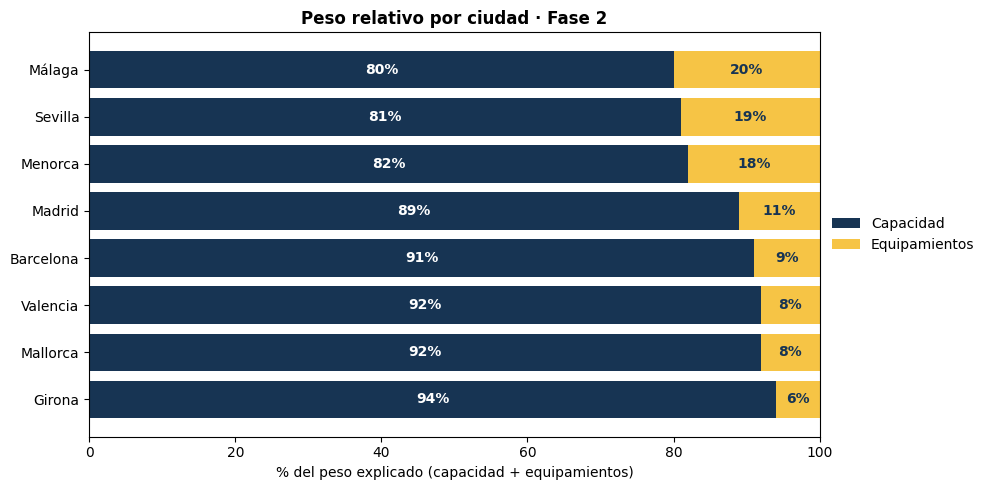

In [13]:
# Gráfico de barras apiladas: capacidad vs equipamientos por ciudad
NAVY, GREEN, YELLOW = "#173453", "#2F8F8F", "#F6C445"
dd = d.sort_values("amen_%")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dd["ciudad"], dd["cap_%"], color=NAVY, label="Capacidad")
ax.barh(dd["ciudad"], dd["amen_%"], left=dd["cap_%"], color=YELLOW, label="Equipamientos")
for i, (_, r) in enumerate(dd.iterrows()):
    ax.text(r["cap_%"] / 2, i, f"{r['cap_%']:.0f}%", va="center", ha="center", color="white", fontweight="bold")
    ax.text(r["cap_%"] + r["amen_%"] / 2, i, f"{r['amen_%']:.0f}%", va="center", ha="center", color=NAVY, fontweight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("% del peso explicado (capacidad + equipamientos)")
ax.set_title("Peso relativo por ciudad · Fase 2", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
(raiz_proyecto / 'Results').mkdir(exist_ok=True)
fig.savefig(raiz_proyecto / 'Results' / 'marketing_fase2_peso_por_ciudad.png', dpi=130, bbox_inches="tight")
plt.show()

## 7. Visualización — Heatmap característica × ciudad

Heatmap que resume la Fase 2: filas = características (capacidad + cada bloque de amenities),
columnas = ciudades, valores = **β estandarizado** de cada característica en el modelo local de esa
ciudad (efecto sobre el log-precio, comparable entre celdas). Es la pieza visual central del análisis.

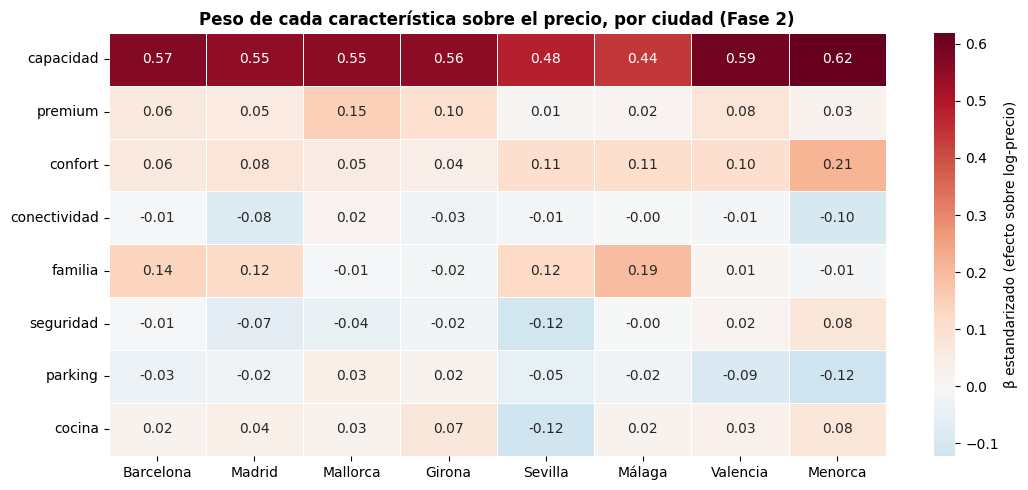

In [14]:
heat = pd.DataFrame(beta_matrix)            # index = predictores, columns = ciudades
heat.index = [ix.replace('cat_', '') if ix != 'accommodates' else 'capacidad' for ix in heat.index]
# ordenar columnas por tamaño de muestra (de mayor a menor) para lectura
orden_ciudades = fase2.sort_values('n', ascending=False)['ciudad'].tolist()
heat = heat[orden_ciudades]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=.5, cbar_kws={"label": "β estandarizado (efecto sobre log-precio)"}, ax=ax)
ax.set_title("Peso de cada característica sobre el precio, por ciudad (Fase 2)", fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()
fig.savefig(raiz_proyecto / 'Results' / 'marketing_heatmap_caracteristica_ciudad.png', dpi=130, bbox_inches="tight")
plt.show()

## 8. Validación de robustez

Chequeos finales sobre el modelo global:
- **Breusch-Pagan** para confirmar que los errores robustos (HC3) eran necesarios.
- Revisión de **residuos** (distribución y patrón vs. ajustados).
- Sensibilidad a **outliers**: se reajusta el modelo excluyendo el 1 % de precios más extremos,
  sólo como control (no como tratamiento), para comprobar que las conclusiones no cambian.

In [15]:
# Breusch-Pagan
bp_p = het_breuschpagan(m1.resid, m1.model.exog)[3]
jb = sm.stats.stattools.jarque_bera(m1.resid)
print(f"Breusch-Pagan p = {bp_p:.2e}  -> heterocedasticidad (por eso usamos HC3)")
print(f"Residuos: skew {jb[2]:.2f}  ·  kurtosis {jb[3]:.2f}")

# Sensibilidad a outliers (1% superior de precio)
umbral = df['price_€'].quantile(0.99)
m1_sens = smf.ols(formula1, data=df[df['price_€'] <= umbral]).fit(cov_type="HC3")
comp = pd.DataFrame({
    "beta_std_full": mz.params[['accommodates'] + catcols].round(3),
    "coef_full": m1.params[['accommodates'] + catcols].round(3),
    "coef_sin_top1%": m1_sens.params[['accommodates'] + catcols].round(3),
})
print(f"\nSensibilidad (excluyendo precios > {umbral:.0f} €, R² full {m1.rsquared:.3f} vs sin-top1% {m1_sens.rsquared:.3f}):")
comp

Breusch-Pagan p = 3.49e-11  -> heterocedasticidad (por eso usamos HC3)
Residuos: skew 0.15  ·  kurtosis 4.71

Sensibilidad (excluyendo precios > 4287 €, R² full 0.495 vs sin-top1% 0.494):


,beta_std_full,coef_full,coef_sin_top1%
accommodates,0.559,0.170,0.167
cat_premium,0.067,0.101,0.098
cat_confort,0.064,0.165,0.171
cat_conectividad,-0.025,-0.160,-0.179
cat_familia,0.094,0.145,0.146
cat_seguridad,-0.029,-0.043,-0.045
cat_parking,-0.018,-0.027,-0.025
cat_cocina,0.028,0.105,0.129


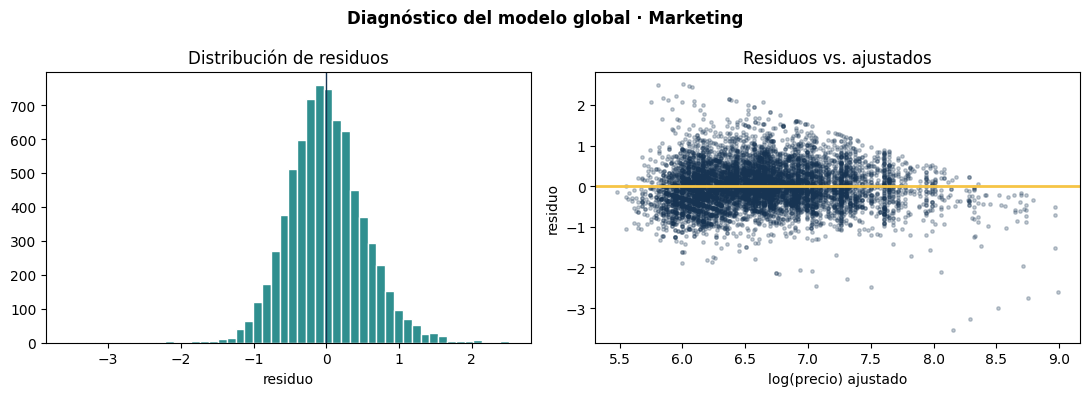

In [16]:
# Diagnóstico visual de residuos
NAVY, GREEN, YELLOW = "#173453", "#2F8F8F", "#F6C445"
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(m1.resid, bins=50, color=GREEN, edgecolor="white"); ax[0].axvline(0, color=NAVY, lw=1)
ax[0].set_title("Distribución de residuos"); ax[0].set_xlabel("residuo")
ax[1].scatter(m1.fittedvalues, m1.resid, s=6, alpha=.25, color=NAVY); ax[1].axhline(0, color=YELLOW, lw=2)
ax[1].set_title("Residuos vs. ajustados"); ax[1].set_xlabel("log(precio) ajustado"); ax[1].set_ylabel("residuo")
fig.suptitle("Diagnóstico del modelo global · Marketing", fontweight="bold")
fig.tight_layout()
fig.savefig(raiz_proyecto / 'Results' / 'marketing_fase1_diagnostico_residuos.png', dpi=130)
plt.show()

## 9. Conclusiones del análisis

Resumen dinámico de los hallazgos, generado a partir de los resultados ejecutados arriba.

In [17]:
# NOTA: con n grande casi TODAS las categorías salen significativas (p<0.05); por eso el titular se
# construye por TAMAÑO DE EFECTO (|β estandarizado|), no por el p-valor, que es lo relevante para negocio.
UMBRAL = 0.05
cats_orden = tabla.loc[catcols].sort_values('beta_std', ascending=False)
con_peso = [ix.replace('cat_', '') for ix in cats_orden.index if cats_orden.loc[ix, 'beta_std'] >= UMBRAL]
marginales = [ix.replace('cat_', '') for ix in cats_orden.index if abs(cats_orden.loc[ix, 'beta_std']) < UMBRAL]
mas_amen = fase2.sort_values('eta2_amen', ascending=False).iloc[0]
menos_amen = fase2.sort_values('eta2_amen').iloc[0]

print("=== TITULARES DEL ANÁLISIS ===\n")
print(f"1. La CAPACIDAD (accommodates) domina el precio: β_std={tabla.loc['accommodates','beta_std']:.2f}, "
      f"η²={eta['capacidad']}% de la varianza global.")
print(f"2. Los EQUIPAMIENTOS van 2º (η² global {eta['amenities (bloque)']}%). Con peso apreciable "
      f"(β_std≥{UMBRAL}): {', '.join(con_peso)}.")
print(f"   Casi universales / sin poder discriminante: {', '.join(marginales)} "
      f"(significativos por el gran n, pero con efecto ~0).")
print(f"3. La CIUDAD pesa sobre todo ENTRE mercados (η² {eta['ciudad']}%; nivel de precio), no tanto dentro.")
print(f"4. Los equipamientos pesan más en {mas_amen['ciudad']} (η²_amen {mas_amen['eta2_amen']}%) "
      f"y menos en {menos_amen['ciudad']} (η²_amen {menos_amen['eta2_amen']}%).")
print(f"5. Supuestos OK: log corrige asimetría ({stats.skew(df['price_€']):.2f}->{stats.skew(df['logp']):.2f}); "
      f"VIF bajo; HC3 por heterocedasticidad (BP p={bp_p:.1e}).")

=== TITULARES DEL ANÁLISIS ===

1. La CAPACIDAD (accommodates) domina el precio: β_std=0.56, η²=28.2% de la varianza global.
2. Los EQUIPAMIENTOS van 2º (η² global 2.1%). Con peso apreciable (β_std≥0.05): familia, premium, confort.
   Casi universales / sin poder discriminante: cocina, parking, conectividad, seguridad (significativos por el gran n, pero con efecto ~0).
3. La CIUDAD pesa sobre todo ENTRE mercados (η² 3.5%; nivel de precio), no tanto dentro.
4. Los equipamientos pesan más en Menorca (η²_amen 8.0%) y menos en Girona (η²_amen 1.9%).
5. Supuestos OK: log corrige asimetría (2.08->0.07); VIF bajo; HC3 por heterocedasticidad (BP p=3.5e-11).


### Respuesta a la pregunta de negocio y limitaciones

**¿Qué características están más relacionadas con el precio en cada ciudad?**
- **La capacidad (`accommodates`) es, con diferencia, el principal factor** en todas las ciudades.
- **Los equipamientos son el segundo factor y su peso varía por ciudad** (ver heatmap y barras): las
  categorías con peso apreciable son las de valor añadido (**familia, premium, confort**), mientras
  que las casi universales (**conectividad, cocina, parking, seguridad**) apenas discriminan precio
  (efecto ~0, aunque salgan significativas por el gran tamaño muestral).
- **La ubicación (ciudad) explica el precio sobre todo *entre* mercados** (nivel general de precios),
  más que *dentro* de cada ciudad.

**Limitaciones (según la justificación técnica):**
- El modelo muestra **asociación controlada, no causalidad**: añadir un extra no garantiza una subida
  automática de precio.
- El **R² es parcial**: el alcance se acota deliberadamente a las 4 variables acordadas
  (`price`, `accommodates`, `city`, `amenities_list`); el resto de la varianza corresponde a factores
  no incluidos.
- **Fiabilidad menor en ciudades de muestra pequeña** (Menorca, Valencia, Málaga, Sevilla).
- `neighbourhood_district` está todo nulo en varias ciudades, por lo que **no se modela la ubicación
  intra-ciudad**.

**Mejoras futuras:** ampliar variables (reseñas, estacionalidad, ubicación intra-ciudad) y evolucionar
a un **modelo multinivel** (efectos aleatorios por ciudad) en lugar de fragmentar la muestra.